In [2]:
import os
import dotenv
import pandas as pd
import pyodbc
import datetime
from zoneinfo import ZoneInfo
import matplotlib.pyplot as plt
import seaborn as sns

dotenv.load_dotenv()


# Connection string using the specific InterSystems ODBC driver
# Note: Ensure the driver name exactly matches what is installed on your client
# Updated with the correct driver name from your system
connection_string = (
    f"DRIVER={{InterSystems IRIS ODBC35}};"
    f"SERVER={os.getenv('IRIS_SERVER')};"
    f"PORT={os.getenv('IRIS_PORT')};"
    f"DATABASE={os.getenv('IRIS_NAMESPACE')};"
    f"UID={os.getenv('IRIS_USERNAME')};"
    f"PWD={os.getenv('IRIS_PASSWORD')}"
)

In [3]:
past_date_str = "2024-01-01 00:00:00"
past_datetime = datetime.datetime.strptime(past_date_str, "%Y-%m-%d %H:%M:%S")
current_datetime = datetime.datetime.now(tz=ZoneInfo(os.getenv("TZ")))
datetime_now_str = current_datetime.strftime("%Y-%m-%d %H:%M:%S")

with pyodbc.connect(connection_string) as cnxn:
    PointSamples_df = pd.read_sql(f"SELECT * FROM MLpipeline.PointSamples WHERE datetime >= '{past_datetime}' AND datetime <= '{datetime_now_str}'", cnxn)
    points_w_groundtruth = PointSamples_df[PointSamples_df.y.notna()].ID
    Predictions_df = pd.read_sql(f"SELECT * FROM MLpipeline.Predictions WHERE pointsidforeignkey IN {tuple(points_w_groundtruth)}", cnxn)

C:\Users\jjaramil\AppData\Local\Temp\ipykernel_25112\1578156191.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  PointSamples_df = pd.read_sql(f"SELECT * FROM MLpipeline.PointSamples WHERE datetime >= '{past_datetime}' AND datetime <= '{datetime_now_str}'", cnxn)
C:\Users\jjaramil\AppData\Local\Temp\ipykernel_25112\1578156191.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  Predictions_df = pd.read_sql(f"SELECT * FROM MLpipeline.Predictions WHERE pointsidforeignkey IN {tuple(points_w_groundtruth)}", cnxn)


In [4]:
points_w_groundtruth

0        1
1        2
2        3
3        4
4        5
      ... 
358    359
359    360
360    361
361    362
362    363
Name: ID, Length: 363, dtype: int64

In [5]:
eachmodelspred = Predictions_df.pivot_table(index="PointsIDForeignKey", columns="Modelrunid", values="YPred", aggfunc="mean")
merged_df = pd.merge(PointSamples_df, eachmodelspred, left_on="ID", right_on="PointsIDForeignKey", how="left")
modelnames = [col for col in merged_df.columns if col not in PointSamples_df.columns]

# Grained Comparison Plot

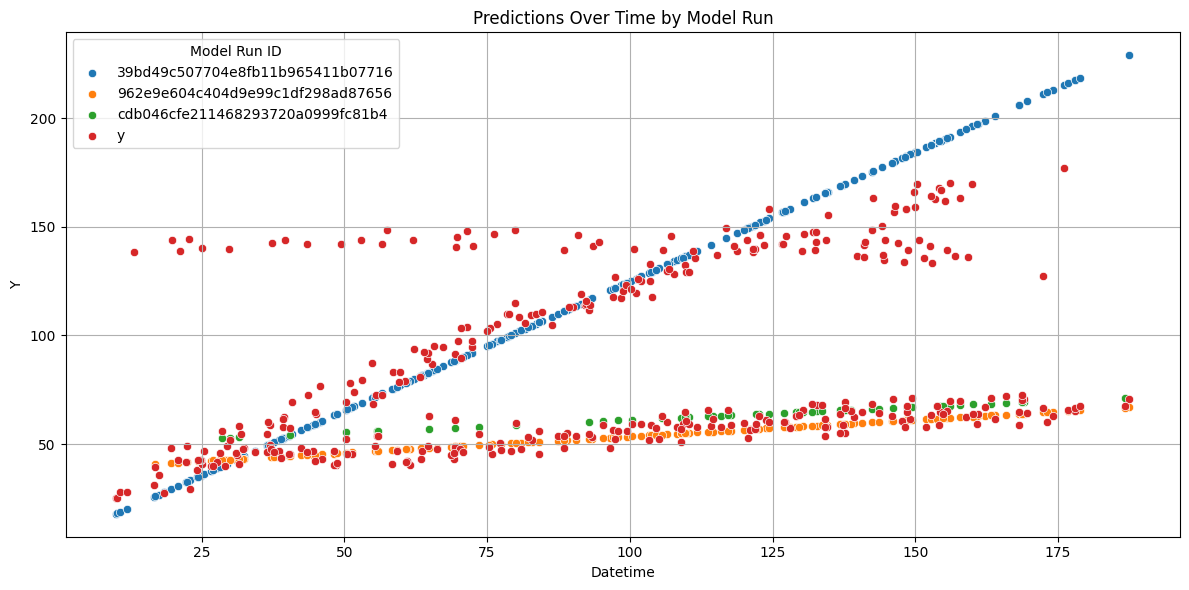

In [6]:
plt.figure(figsize=(12, 6))
for colname in modelnames + ["y"]:
    sns.scatterplot(data=merged_df, x="x", y=colname, label=colname)
plt.title("Predictions Over Time by Model Run")
plt.xlabel("Datetime")
plt.ylabel("Y")
plt.legend(title="Model Run ID")
plt.xticks()
plt.grid()
plt.tight_layout()

In [7]:
models_last_datetime = Predictions_df.groupby("Modelrunid").agg({"datetime":max})
latest_model = models_last_datetime["datetime"].idxmax()
latest_active_predictions = Predictions_df[Predictions_df["Modelrunid"] == latest_model].groupby("PointsIDForeignKey").agg({"YPred": "mean", "InferenceTime": "mean"}).reset_index()
latest_active_predictions = pd.merge(latest_active_predictions, PointSamples_df[["ID", "y"]], left_on="PointsIDForeignKey", right_on="ID", how="left")


C:\Users\jjaramil\AppData\Local\Temp\ipykernel_25112\1703254604.py:1: FutureWarning: The provided callable <built-in function max> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  models_last_datetime = Predictions_df.groupby("Modelrunid").agg({"datetime":max})


In [8]:
latest_active_predictions

,PointsIDForeignKey,YPred,InferenceTime,ID,y
0,251,52.919406,0.000028,251,52.013929
1,252,52.754396,0.000028,252,56.040955
2,253,53.095485,0.000028,253,58.232584
3,254,54.155360,0.000028,254,57.591145
4,255,55.308989,0.000028,255,52.289300
5,256,55.950162,0.000028,256,53.908036
6,257,55.961133,0.000028,257,53.808225
7,258,57.008208,0.000028,258,63.040384
8,259,57.553076,0.000028,259,60.950073
9,260,58.037512,0.000028,260,54.618895


In [9]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(latest_active_predictions["y"], latest_active_predictions["YPred"])
r2 = r2_score(latest_active_predictions["y"], latest_active_predictions["YPred"])
print(f"Mean Absolute Error: {mae}")
print(f"R-squared: {r2}")


Mean Absolute Error: 2.7458644782915624
R-squared: 0.684103807493704
